<a href="https://colab.research.google.com/github/tannialhernandez/topicosAvanzadosAnalitica/blob/main/E4_SpamClassification/E4_SpamClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3
## Spam Classification
### Context
The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.

### Content
The files contain one message per line. Each line is composed by two columns: v1 contains the label (ham or spam) and v2 contains the raw text.

This corpus has been collected from free or free for research sources at the Internet:

- A collection of 425 SMS spam messages was manually extracted from the Grumbletext Web site. This is a UK forum in which cell phone users make public claims about SMS spam messages, most of them without reporting the very spam message received. The identification of the text of spam messages in the claims is a very hard and time-consuming task, and it involved carefully scanning hundreds of web pages. The Grumbletext Web site is: [Web Link](http://www.grumbletext.co.uk/).
- A subset of 3,375 SMS randomly chosen ham messages of the NUS SMS Corpus (NSC), which is a dataset of about 10,000 legitimate messages collected for research at the Department of Computer Science at the National University of Singapore. The messages largely originate from Singaporeans and mostly from students attending the University. These messages were collected from volunteers who were made aware that their contributions were going to be made publicly available. The NUS SMS Corpus is avalaible at: [Web Link](http://www.comp.nus.edu.sg/~rpnlpir/downloads/corpora/smsCorpus/).
- A list of 450 SMS ham messages collected from Caroline Tag's PhD Thesis available at [Web Link](http://etheses.bham.ac.uk/253/1/Tagg09PhD.pdf).
- Finally, we have incorporated the SMS Spam Corpus v.0.1 Big. It has 1,002 SMS ham messages and 322 spam messages and it is public available at: [Web Link](http://www.esp.uem.es/jmgomez/smsspamcorpus/). This corpus has been used in the following academic researches:

Acknowledgements
The original dataset can be found [here](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection). The creators would like to note that in case you find the dataset useful, please make a reference to previous paper and the web page: http://www.dt.fee.unicamp.br/~tiago/smsspamcollection/ in your papers, research, etc.

We offer a comprehensive study of this corpus in the following paper. This work presents a number of statistics, studies and baseline results for several machine learning methods.

Almeida, T.A., GÃ³mez Hidalgo, J.M., Yamakami, A. Contributions to the Study of SMS Spam Filtering: New Collection and Results. Proceedings of the 2011 ACM Symposium on Document Engineering (DOCENG'11), Mountain View, CA, USA, 2011.

In [1]:
!pip install wget

In [2]:
!pip install numpy==1.24.3

In [3]:
!pip install gensim

In [307]:
import pandas as pd
import numpy as np
import wget
import os
import seaborn as sns
from zipfile import ZipFile

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import string

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, roc_curve, confusion_matrix,roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight

import gensim
from gensim.models import Word2Vec
import warnings


warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [308]:
def download_and_extract():
    zip_path = "smsspamcollection.zip"
    data_path = "SMSSpamCollection"
    readme_path = "README"

    # Verifica si el archivo ya está extraído
    if not os.path.exists(data_path):
        try:
            from google.colab import files
            !wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
            !unzip -o smsspamcollection.zip
        except ModuleNotFoundError:
            import wget
            url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
            if not os.path.exists(zip_path):
                wget.download(url, zip_path)
            with ZipFile(zip_path, "r") as file:
                file.extractall()

In [352]:
def plot_confusion_matrix(y_test, y_pred, labels=['No Spam', 'Spam']):

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión')
    plt.show()

def plot_roc_curve(y_test, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc_value = roc_auc_score(y_test, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_value:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

In [415]:
download_and_extract()
df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["target", "text"])
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [311]:
display(df.shape)
df["target"].value_counts()/df.shape[0]

(5572, 2)

,count
target,
ham,0.865937
spam,0.134063


In [312]:
X = df['text']
y = df['target'].map({'ham':0, 'spam':1})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = df['target'], test_size = 0.3, random_state = 18)

Preprocess the text data by removing stop words, converting all text to lowercase, and removing punctuation using NLTK package.


In [314]:
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = ''.join([word for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

In [315]:
print(X_train)

5453                       except theres chick huge boobs
2881    last chance claim ur £150 worth discount vouch...
3376                                                     
2591    lol take member said aunt flow didnt visit 6 m...
3188                                   howz persons story
                              ...                        
4065    prof passed papers sem congrats student enna k...
852                    real baby want bring inner tigress
310                           garage keys arent bookshelf
4789    thanx yup coming back sun finish dinner going ...
3105               thats said bad dat e gals know u wat u
Name: text, Length: 3900, dtype: object


In [316]:
print(X_test)

3087    wish holding tightly making see important much...
4062    aight ive set free think could text blakes add...
572                                 know lab goggles went
2453                            okay ive seen pick friday
4593               right wasnt phoned someone number like
                              ...                        
5405                                      many days since
2771                                   problem talk later
3373                                 electricity went fml
1204            thanks understanding ive trying tell sura
2400                                     oh kay sat right
Name: text, Length: 1672, dtype: object


Train a Word2Vec model on the preprocessed training data using Gensim package.

In [317]:
sentences = [sentence.split() for sentence in X_train]
model = Word2Vec(sentences, vector_size=300, window=10, negative=20, min_count=1, workers=4)

Convert the preprocessed text data to a vector representation using the Word2Vec model.

In [318]:
def vectorize(sentence):
    words = sentence.split()
    words_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(words_vecs) == 0:
        return np.zeros(300)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis=0)

X_train = np.array([vectorize(sentence) for sentence in X_train])
X_test = np.array([vectorize(sentence) for sentence in X_test])

Train a classification model such as logistic regression, random forests, or support vector machines using the vectorised training data and the sentiment labels.

## Using `class_weight='balanced'` in `LogisticRegression`  

### Problem  
The dataset was imbalanced:  
- **86.6%** "ham" (not spam)  
- **13.4%** "spam"  

This caused the model to favor the majority class, resulting in an **AUC of 0.5** (random classification).  

### Solution  
`class_weight='balanced'` was used to adjust the importance of each class:


In [319]:
clf = LogisticRegression(class_weight='balanced', max_iter=100, random_state=42)
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [320]:
print(clf.n_iter_)

[18]


Evaluate the performance of the classification model on the testing set with the accuracy, precision, recall and F1 score.

In [322]:
y_pred = clf.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))

Accuracy: 0.8761961722488039
AUC: 0.8379538279400157


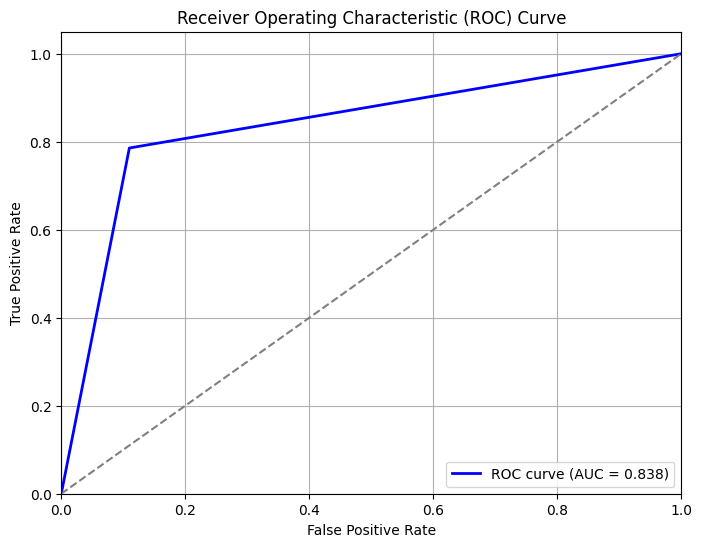

In [353]:
plot_roc_curve(y_test, y_pred)

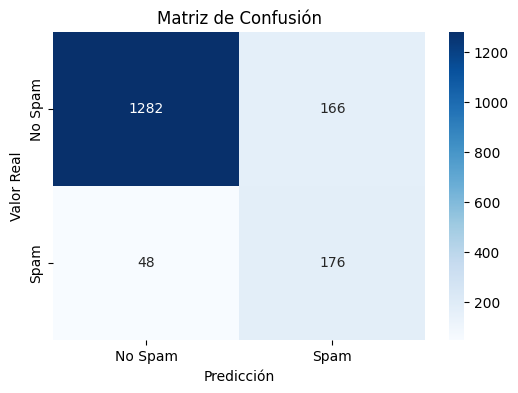

In [272]:
plot_confusion_matrix(y_test, y_pred)

# Excercise 3.1

Remove stopwords, then predict target using CountVectorizer.

use Random Forest classifier

In [244]:
download_and_extract()
df_rm_stopword = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["target", "text"])

df_rm_stopword['target'] = df_rm_stopword['target'].map({'ham': 0, 'spam': 1})

def preprocess(text):
    words = text.lower().split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df_rm_stopword['text'] = df_rm_stopword['text'].apply(preprocess)

print(df_rm_stopword)

      target                                               text
0          0  go jurong point, crazy.. available bugis n gre...
1          0                      ok lar... joking wif u oni...
2          1  free entry 2 wkly comp win fa cup final tkts 2...
3          0          u dun say early hor... u c already say...
4          0            nah think goes usf, lives around though
...      ...                                                ...
5567       1  2nd time tried 2 contact u. u £750 pound prize...
5568       0                       ü b going esplanade fr home?
5569       0           pity, * mood that. so...any suggestions?
5570       0  guy bitching acted like interested buying some...
5571       0                                    rofl. true name

[5572 rows x 2 columns]


In [245]:
X_train_rm_stopword, X_test_rm_stopword, y_train_rm_stopword, y_test_rm_stopword = train_test_split(df_rm_stopword['text'], df_rm_stopword['target'], test_size=0.2, random_state=42)

In [246]:
vectorizer = CountVectorizer()
X_train_vec_rm_stopword = vectorizer.fit_transform(X_train_rm_stopword)
X_test_vec_rm_stopword = vectorizer.transform(X_test_rm_stopword)

In [247]:
clf_rm_stopword  = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
clf_rm_stopword .fit(X_train_vec_rm_stopword, y_train_rm_stopword)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [434]:
y_pred_rm_stopword = clf_rm_stopword.predict(X_test_vec_rm_stopword)
fpr_rm_stopword, tpr_rm_stopword, thresholds = roc_curve(y_test_rm_stopword, y_pred_rm_stopword)

print('Accuracy:', accuracy_score(y_test_rm_stopword, y_pred_rm_stopword))
print('AUC:', auc(fpr_rm_stopword, tpr_rm_stopword))

Accuracy: 0.9802690582959641
AUC: 0.9261744966442953


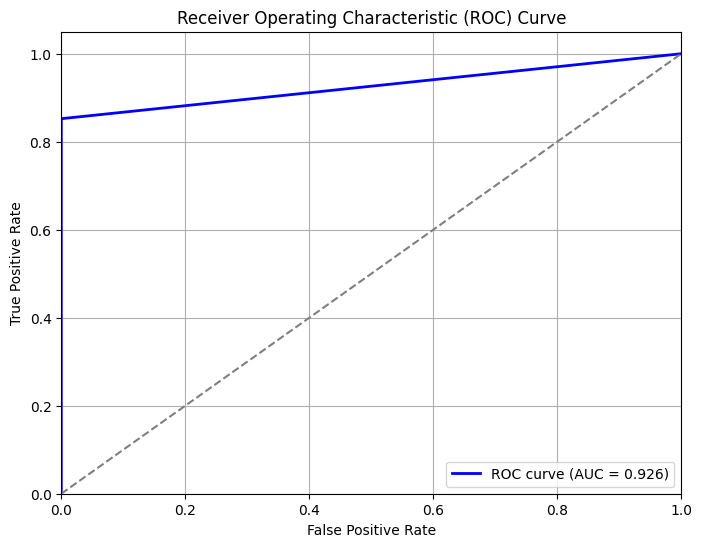

In [354]:
plot_roc_curve(y_test_rm_stopword, y_pred_rm_stopword)

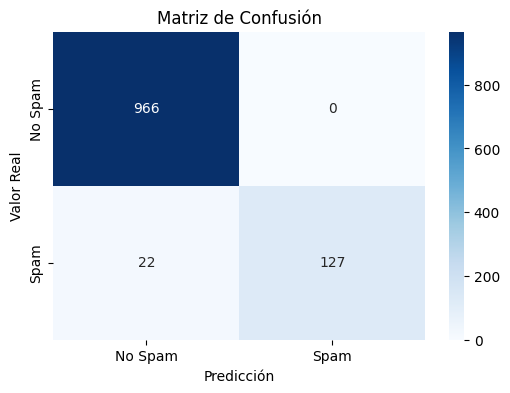

In [257]:
plot_confusion_matrix(y_test_rm_stopword, y_pred_rm_stopword)

# Excercise 3.2

Predict target using TdidfVectorizer.

use Random Forest classifier

In [332]:
download_and_extract()
df_Tdid = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["target", "text"])

df_Tdid['target'] = df_Tdid['target'].map({'ham': 0, 'spam': 1})

def preprocess(text):
    words = text.lower().split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df_Tdid['text'] = df_Tdid['text'].apply(preprocess)

print(df_Tdid)

      target                                               text
0          0  go jurong point, crazy.. available bugis n gre...
1          0                      ok lar... joking wif u oni...
2          1  free entry 2 wkly comp win fa cup final tkts 2...
3          0          u dun say early hor... u c already say...
4          0            nah think goes usf, lives around though
...      ...                                                ...
5567       1  2nd time tried 2 contact u. u £750 pound prize...
5568       0                       ü b going esplanade fr home?
5569       0           pity, * mood that. so...any suggestions?
5570       0  guy bitching acted like interested buying some...
5571       0                                    rofl. true name

[5572 rows x 2 columns]


In [333]:
X_train_Tdid, X_test_Tdid, y_train_Tdid, y_test_Tdid = train_test_split(df_Tdid['text'], df_Tdid['target'], test_size=0.2, random_state=42)

In [336]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train_Tdid)
X_test_tfidf = vectorizer.transform(X_test_Tdid)

In [338]:
clf_tfidf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train_Tdid)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [345]:
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
accuracy = accuracy_score(y_test_Tdid, y_pred_tfidf)
auc = roc_auc_score(y_test_Tdid, y_pred_tfidf)

print(f'Accuracy: {accuracy:.4f}')
print(f'AUC: {auc:.4f}')


Accuracy: 0.9830
AUC: 0.9362


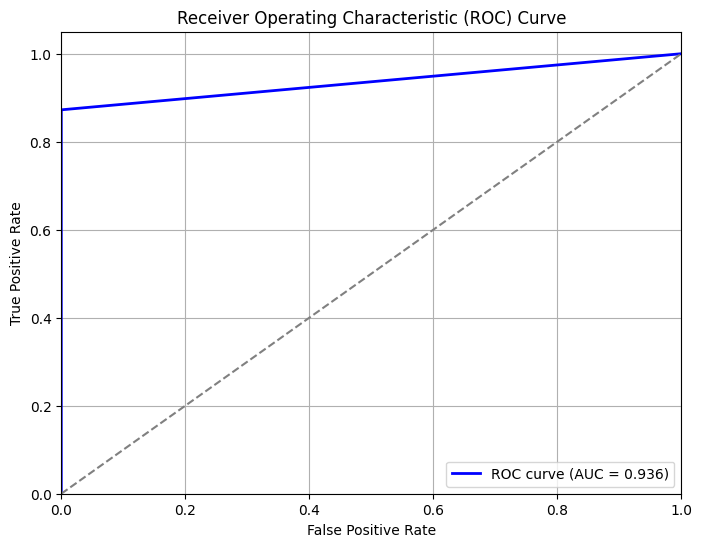

In [355]:
plot_roc_curve(y_test_Tdid, y_pred_tfidf)

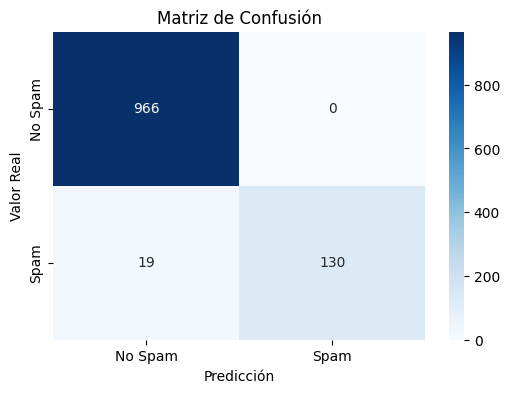

In [341]:
plot_confusion_matrix(y_test_Tdid, y_pred_tfidf)

# Excercise 3.3

Predict target using CountVectorizer or TfideVectorizer.

choose any classification model and justify why

Answer:
The multilayer perceptron is ideal due to its ability to handle nonlinear and high-dimensional data, such as those generated by CountVectorizer or TfidfVectorizer. Its multilayer architecture with ReLU activation enables learning complex representations, while the Adam optimizer ensures stable training. Additionally, by assigning balanced weights, it improves performance on imbalanced datasets.

In [356]:
download_and_extract()
df_conortf = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["target", "text"])

df_conortf['target'] = df_conortf['target'].map({'ham': 0, 'spam': 1})

def preprocess(text):
    words = text.lower().split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df_conortf['text'] = df_conortf['text'].apply(preprocess)

print(df_conortf)

      target                                               text
0          0  go jurong point, crazy.. available bugis n gre...
1          0                      ok lar... joking wif u oni...
2          1  free entry 2 wkly comp win fa cup final tkts 2...
3          0          u dun say early hor... u c already say...
4          0            nah think goes usf, lives around though
...      ...                                                ...
5567       1  2nd time tried 2 contact u. u £750 pound prize...
5568       0                       ü b going esplanade fr home?
5569       0           pity, * mood that. so...any suggestions?
5570       0  guy bitching acted like interested buying some...
5571       0                                    rofl. true name

[5572 rows x 2 columns]


In [365]:
X_train_conortf, X_test_conortf, y_train_conortf, y_test_conortf = train_test_split(df_conortf['text'], df_conortf['target'], test_size=0.2, random_state=42)

         Método  Accuracy      AUC
CountVectorizer  0.989238 0.981700
TfidfVectorizer  0.991031 0.990836

Mejor método:
TfidfVectorizer
       0.991031
       0.990836


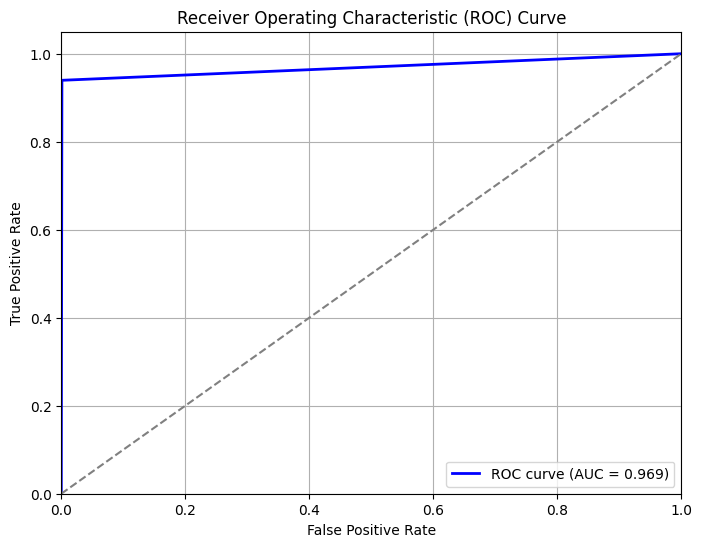

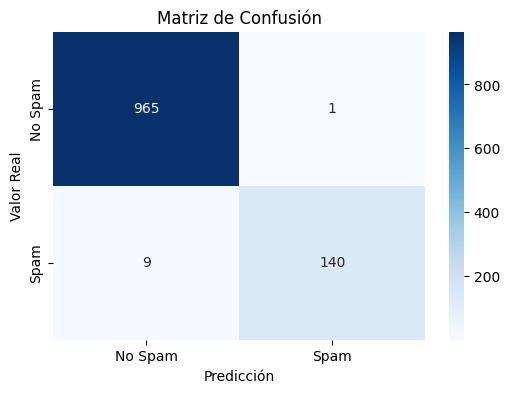

In [402]:
def compare_vectorizers(X_train, X_test, y_train, y_test):
    results = []
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

    def train_evaluate(vectorizer):
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        clf = MLPClassifier(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            solver='adam',
            max_iter=200,
            random_state=42
        )

        clf.fit(X_train_vec, y_train)

        y_pred = clf.predict(X_test_vec)
        y_pred_proba = clf.predict_proba(X_test_vec)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)

        return accuracy, auc, y_pred, y_pred_proba

    accuracy_count, auc_count, y_pred_count, y_pred_proba_count = train_evaluate(CountVectorizer())
    results.append(["CountVectorizer", accuracy_count, auc_count])

    accuracy_tfidf, auc_tfidf, y_pred_tfidf, y_pred_proba_tfidf = train_evaluate(TfidfVectorizer())
    results.append(["TfidfVectorizer", accuracy_tfidf, auc_tfidf])

    df_results = pd.DataFrame(results, columns=["Método", "Accuracy", "AUC"])

    print(df_results.to_string(index=False))

    best_method_idx = df_results["AUC"].idxmax()
    best_method = df_results.loc[best_method_idx]

    print("\nMejor método:")
    print(best_method.to_string(index=False))

    return best_method, (y_pred_tfidf if best_method["Método"] == "TfidfVectorizer" else y_pred_count)

best_method, best_y_pred = compare_vectorizers(X_train_conortf, X_test_conortf, y_train_conortf, y_test_conortf)

plot_roc_curve(y_test_conortf, best_y_pred)

plot_confusion_matrix(y_test_conortf, best_y_pred)

# Excercise 3.4

Increase and decrece the parameters values vector_size, window and negative then predict the target.

Plot the different values of the parameters with the performance of the model.

Use a Random Forest classifier and classification model of your choice and justify why.

Parametros iniciales: vector_size=300, window=10, negative=20



In [432]:
download_and_extract()
df_experimentos = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["target", "text"])

df_experimentos['target'] = df_experimentos['target'].map({'ham': 0, 'spam': 1})

print(df_conortf)

      target                                               text
0          0  go jurong point, crazy.. available bugis n gre...
1          0                      ok lar... joking wif u oni...
2          1  free entry 2 wkly comp win fa cup final tkts 2...
3          0          u dun say early hor... u c already say...
4          0            nah think goes usf, lives around though
...      ...                                                ...
5567       1  2nd time tried 2 contact u. u £750 pound prize...
5568       0                       ü b going esplanade fr home?
5569       0           pity, * mood that. so...any suggestions?
5570       0  guy bitching acted like interested buying some...
5571       0                                    rofl. true name

[5572 rows x 2 columns]


In [ ]:
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(df_experimentos['text'], df_experimentos['target'], test_size=0.2, random_state=42)

In [482]:
def train_and_evaluate(word2vec_params, window=10, negatives=20, clf_type="RandomForest"):
    vector_size = word2vec_params

    sentences = [sentence.split() for sentence in X_train_exp]
    model = Word2Vec(sentences, vector_size=vector_size, window=window, negative=negatives, min_count=1, workers=4)

    def vectorize(sentence):
        words = sentence.split()
        words_vecs = [model.wv[word] for word in words if word in model.wv]
        if len(words_vecs) == 0:
            return np.zeros(vector_size)
        words_vecs = np.array(words_vecs)
        return words_vecs.mean(axis=0)

    X_train_vec = np.array([vectorize(sentence) for sentence in X_train_exp])
    X_test_vec = np.array([vectorize(sentence) for sentence in X_test_exp])

    if clf_type == "RandomForest":
        clf = RandomForestClassifier(class_weight='balanced', random_state=42)
    elif clf_type == "MLP":
        clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=200, random_state=42)

    clf.fit(X_train_vec, y_train_exp)
    y_pred = clf.predict(X_test_vec)

    fpr, tpr, thresholds = roc_curve(y_test_exp, y_pred)
    accuracy = accuracy_score(y_test_exp, y_pred)
    auc_score = auc(fpr, tpr)

    return accuracy, auc_score, clf, y_pred

def run_experiments(vector_sizes=None, window_sizes=None, negatives_sizes=None):
    if vector_sizes is None:
        vector_sizes = [300]
    if window_sizes is None:
        window_sizes = [10]
    if negatives_sizes is None:
        negatives_sizes = [20]

    total_combinations = len(vector_sizes) * len(window_sizes) * len(negatives_sizes) * 2
    print(f"Ejecutando {total_combinations} experimentos ({len(vector_sizes)}×{len(window_sizes)}×{len(negatives_sizes)}×2 clasificadores)...")

    results = []

    try:
        from tqdm import tqdm
        use_tqdm = True
        pbar = tqdm(total=total_combinations, desc="Entrenando modelos")
    except ImportError:
        use_tqdm = False

    for vector_size in vector_sizes:
        for window in window_sizes:
            for negatives in negatives_sizes:
                accuracy_rf, auc_rf, rf_clf, rf_y_pred = train_and_evaluate(vector_size, window=window, negatives=negatives, clf_type="RandomForest")
                results.append([vector_size, window, negatives, accuracy_rf, auc_rf, "RandomForest"])
                if use_tqdm: pbar.update(1)

                accuracy_mlp, auc_mlp, mlp_clf, mlp_y_pred = train_and_evaluate(vector_size, window=window, negatives=negatives, clf_type="MLP")
                results.append([vector_size, window, negatives, accuracy_mlp, auc_mlp, "MLP"])
                if use_tqdm: pbar.update(1)

                if len(results) % 10 == 0:
                    df_partial = pd.DataFrame(results, columns=["Vector Size", "Window", "Negatives", "Accuracy", "AUC", "Classifier"])

    if use_tqdm: pbar.close()

    df_results = pd.DataFrame(results, columns=["Vector Size", "Window", "Negatives", "Accuracy", "AUC", "Classifier"])

    print("\nResumen de resultados:")
    print(df_results.to_string(index=False))

    best_model_idx = df_results["AUC"].idxmax()
    best_model = df_results.loc[best_model_idx]

    print("\n" + "="*50)
    print("MEJOR MODELO:")
    print("="*50)
    print(f"Tipo de clasificador: {best_model['Classifier']}")
    print(f"Vector Size: {best_model['Vector Size']}")
    print(f"Window Size: {best_model['Window']}")
    print(f"Negatives: {best_model['Negatives']}")
    print("-"*50)
    print(f"Accuracy: {best_model['Accuracy']:.4f}")
    print(f"AUC: {best_model['AUC']:.4f}")
    print("="*50)

    best_vector_size = best_model['Vector Size']
    best_window = best_model['Window']
    best_negatives = best_model['Negatives']
    best_classifier_type = best_model['Classifier']

    print(f"\nRe-entrenando el mejor modelo ({best_classifier_type}) para obtener métricas detalladas...")
    best_accuracy, best_auc, best_clf, best_y_pred = train_and_evaluate(
        best_vector_size,
        window=best_window,
        negatives=best_negatives,
        clf_type=best_classifier_type
    )

    print("\nMétricas detalladas del mejor modelo:")
    print(f"Matriz de confusión:\n{confusion_matrix(y_test_exp, best_y_pred)}")

    plt.figure(figsize=(12, 6))

    varying_vector = len(vector_sizes) > 1
    varying_window = len(window_sizes) > 1
    varying_negatives = len(negatives_sizes) > 1

    if varying_vector and not varying_window and not varying_negatives:
        for cls_type in df_results["Classifier"].unique():
            subset = df_results[df_results["Classifier"] == cls_type]
            plt.plot(subset["Vector Size"], subset["AUC"], label=f"{cls_type}", marker='o', linestyle='-')
        plt.xlabel('Tamaño del Vector (Size)')

    elif not varying_vector and varying_window and not varying_negatives:
        for cls_type in df_results["Classifier"].unique():
            subset = df_results[df_results["Classifier"] == cls_type]
            plt.plot(subset["Window"], subset["AUC"], label=f"{cls_type}", marker='o', linestyle='-')
        plt.xlabel('Ventana (Window)')

    elif not varying_vector and not varying_window and varying_negatives:
        for cls_type in df_results["Classifier"].unique():
            subset = df_results[df_results["Classifier"] == cls_type]
            plt.plot(subset["Negatives"], subset["AUC"], label=f"{cls_type}", marker='o', linestyle='-')
        plt.xlabel('Negatives')

    else:
        for cls_type in df_results["Classifier"].unique():
            subset = df_results[df_results["Classifier"] == cls_type]
            subset = subset.sort_values(by=["Vector Size", "Window", "Negatives"])
            subset = subset.copy()
            subset['Combination'] = subset.apply(
                lambda row: f"V{row['Vector Size']}_W{row['Window']}_N{row['Negatives']}", axis=1)

            plt.plot(range(len(subset)), subset["AUC"], label=f"{cls_type}", marker='o', linestyle='-')

        all_combinations = []
        for v in vector_sizes:
            for w in window_sizes:
                for n in negatives_sizes:
                    all_combinations.append(f"V{v}_W{w}_N{n}")

        step = max(1, len(all_combinations) // 10)
        plt.xticks(range(0, len(all_combinations), step),
                  all_combinations[::step],
                  rotation=45, ha='right')
        plt.xlabel('Combinaciones de parámetros')

    plt.ylabel('AUC')
    plt.title('Comparación de AUC para diferentes configuraciones')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('resultados_experimentos.png')
    plt.show()

    if (varying_vector + varying_window + varying_negatives) >= 2:
            print("\nCreando visualización en heatmap para múltiples parámetros...")

            if varying_vector and varying_window and varying_negatives:
                plt.figure(figsize=(15, 10))

                for i, neg in enumerate(negatives_sizes):
                    neg_data = df_results[df_results['Negatives'] == neg]

                    avg_data = neg_data.groupby(['Vector Size', 'Window'])['AUC'].mean().reset_index()
                    pivot_data = avg_data.pivot(index='Window', columns='Vector Size', values='AUC')

                    plt.subplot(2, 4, i % 8 + 1)
                    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis', vmin=0.5, vmax=1.0)
                    plt.title(f'AUC (Negatives={neg})')

                    if (i + 1) % 8 == 0 and i < len(negatives_sizes) - 1:
                        plt.tight_layout()
                        plt.savefig(f'heatmap_negatives_part{(i+1)//8}.png')
                        plt.figure(figsize=(15, 10))

                plt.tight_layout()
                plt.savefig(f'heatmap_negatives_part{(len(negatives_sizes)-1)//8 + 1}.png')
                plt.show()

            elif varying_vector and varying_window:
                plt.figure(figsize=(10, 8))
                avg_data = df_results.groupby(['Vector Size', 'Window'])['AUC'].mean().reset_index()
                pivot_data = avg_data.pivot(index='Window', columns='Vector Size', values='AUC')

                sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis', vmin=0.5, vmax=1.0)
                plt.title('AUC promedio por Vector Size y Window')
                plt.tight_layout()
                plt.show()

            elif varying_vector and varying_negatives:
                plt.figure(figsize=(10, 8))
                avg_data = df_results.groupby(['Vector Size', 'Negatives'])['AUC'].mean().reset_index()
                pivot_data = avg_data.pivot(index='Negatives', columns='Vector Size', values='AUC')

                sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis', vmin=0.5, vmax=1.0)
                plt.title('AUC promedio por Vector Size y Negatives')
                plt.tight_layout()
                plt.show()

            elif varying_window and varying_negatives:
                plt.figure(figsize=(10, 8))
                avg_data = df_results.groupby(['Window', 'Negatives'])['AUC'].mean().reset_index()
                pivot_data = avg_data.pivot(index='Negatives', columns='Window', values='AUC')

                sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis', vmin=0.5, vmax=1.0)
                plt.title('AUC promedio por Window y Negatives')
                plt.tight_layout()
                plt.savefig('heatmap_window_negatives.png')
                plt.show()

parameter variation: `vector_size`

Ejecutando 18 experimentos (9×1×1×2 clasificadores)...


Entrenando modelos: 100%|██████████| 18/18 [02:54<00:00,  9.68s/it]



Resumen de resultados:
 Vector Size  Window  Negatives  Accuracy      AUC   Classifier
          50      10         20  0.943498 0.802781 RandomForest
          50      10         20  0.942601 0.841997          MLP
         100      10         20  0.955157 0.843567 RandomForest
         100      10         20  0.957848 0.859311          MLP
         150      10         20  0.941704 0.793232 RandomForest
         150      10         20  0.926457 0.733347          MLP
         200      10         20  0.957848 0.847958 RandomForest
         200      10         20  0.956054 0.872466          MLP
         250      10         20  0.951570 0.832982 RandomForest
         250      10         20  0.943498 0.814134          MLP
         300      10         20  0.952466 0.842014 RandomForest
         300      10         20  0.955157 0.871948          MLP
         350      10         20  0.956951 0.861631 RandomForest
         350      10         20  0.951570 0.832982          MLP
         400    

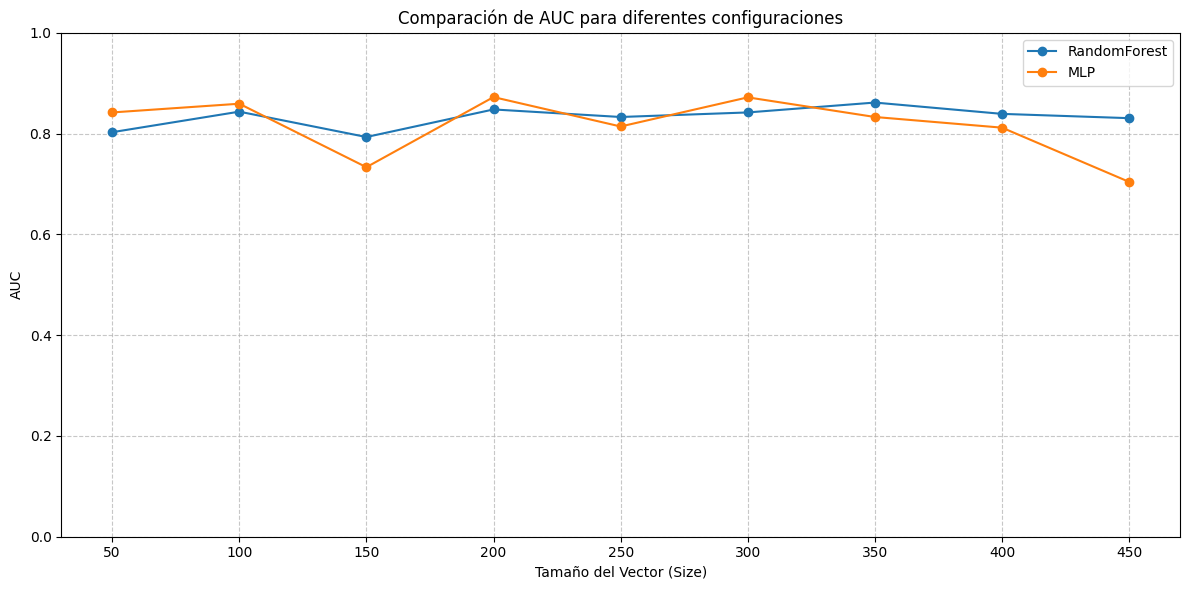

In [483]:
run_experiments(vector_sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450])

parameter variation: `window`

Ejecutando 12 experimentos (1×6×1×2 clasificadores)...


Entrenando modelos: 100%|██████████| 12/12 [01:42<00:00,  8.56s/it]



Resumen de resultados:
 Vector Size  Window  Negatives  Accuracy      AUC   Classifier
         300      10         20  0.948879 0.820077 RandomForest
         300      10         20  0.947982 0.839426          MLP
         300      20         20  0.956951 0.855955 RandomForest
         300      20         20  0.951570 0.875554          MLP
         300      30         20  0.958744 0.868342 RandomForest
         300      30         20  0.951570 0.884068          MLP
         300      40         20  0.959641 0.863184 RandomForest
         300      40         20  0.952466 0.856205          MLP
         300      50         20  0.958744 0.859828 RandomForest
         300      50         20  0.940807 0.869343          MLP
         300      60         20  0.956951 0.855955 RandomForest
         300      60         20  0.950673 0.852332          MLP

MEJOR MODELO:
Tipo de clasificador: MLP
Vector Size: 300
Window Size: 30
Negatives: 20
--------------------------------------------------
Accur

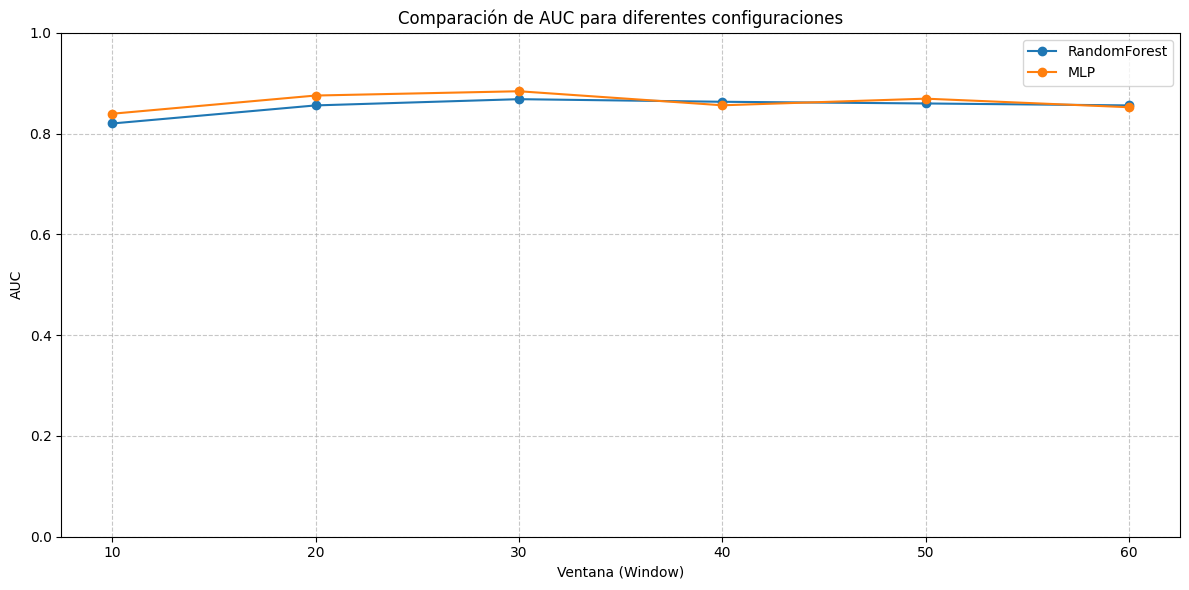

In [484]:
run_experiments(window_sizes=[10, 20, 30, 40, 50, 60])

parameter variation: `negative`

Ejecutando 14 experimentos (1×1×7×2 clasificadores)...


Entrenando modelos: 100%|██████████| 14/14 [02:50<00:00, 12.21s/it]



Resumen de resultados:
 Vector Size  Window  Negatives  Accuracy      AUC   Classifier
         300      10         10  0.953363 0.831180 RandomForest
         300      10         10  0.947085 0.853099          MLP
         300      10         20  0.950673 0.829627 RandomForest
         300      10         20  0.947085 0.821880          MLP
         300      10         30  0.956951 0.850279 RandomForest
         300      10         30  0.947982 0.916055          MLP
         300      10         40  0.949776 0.817757 RandomForest
         300      10         40  0.942601 0.816454          MLP
         300      10         50  0.939910 0.783682 RandomForest
         300      10         50  0.914798 0.695399          MLP
         300      10         60  0.931839 0.750643 RandomForest
         300      10         60  0.866368 0.500000          MLP
         300      10         70  0.904933 0.644295 RandomForest
         300      10         70  0.866368 0.500000          MLP

MEJOR MODELO:
T

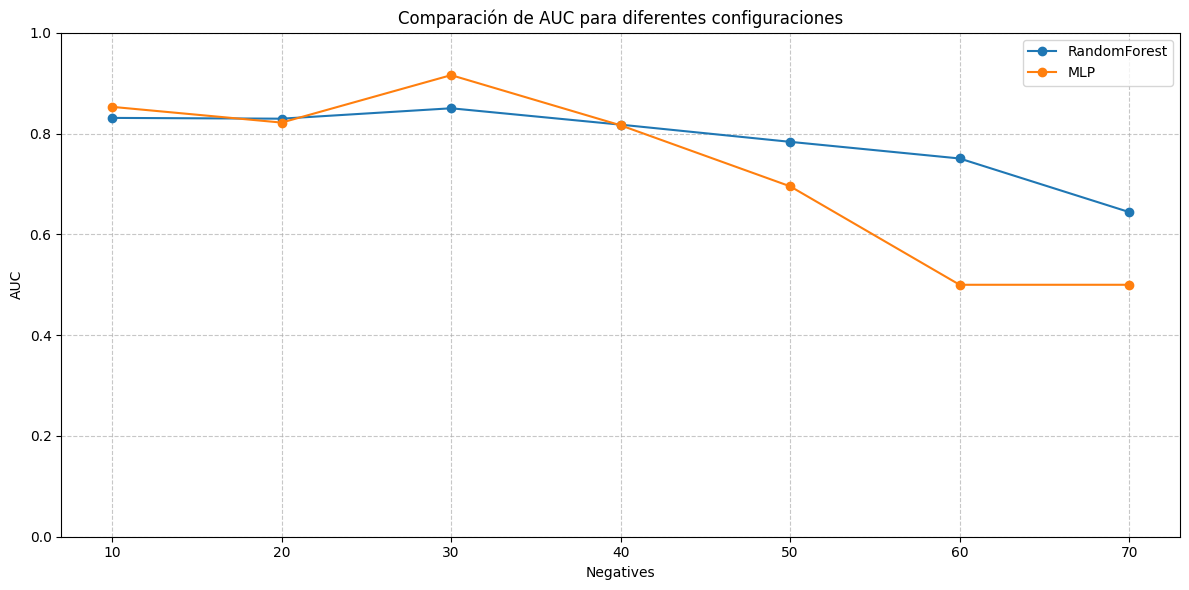

In [485]:
run_experiments(negatives_sizes=[10, 20, 30, 40, 50, 60, 70])

Running best parameters `vector_size, window and negative` (All at the same time)

Ejecutando 54 experimentos (3×3×3×2 clasificadores)...


Entrenando modelos: 100%|██████████| 54/54 [06:17<00:00,  6.99s/it]



Resumen de resultados:
 Vector Size  Window  Negatives  Accuracy      AUC   Classifier
         100      10         10  0.947982 0.822398 RandomForest
         100      10         10  0.943498 0.842515          MLP
         100      10         20  0.954260 0.840211 RandomForest
         100      10         20  0.953363 0.845370          MLP
         100      10         30  0.947085 0.813366 RandomForest
         100      10         30  0.942601 0.813616          MLP
         100      20         10  0.961435 0.872733 RandomForest
         100      20         10  0.942601 0.833483          MLP
         100      20         20  0.960538 0.872216 RandomForest
         100      20         20  0.950673 0.843817          MLP
         100      20         30  0.953363 0.845370 RandomForest
         100      20         30  0.950673 0.869360          MLP
         100      30         10  0.956951 0.861631 RandomForest
         100      30         10  0.949776 0.868843          MLP
         100    

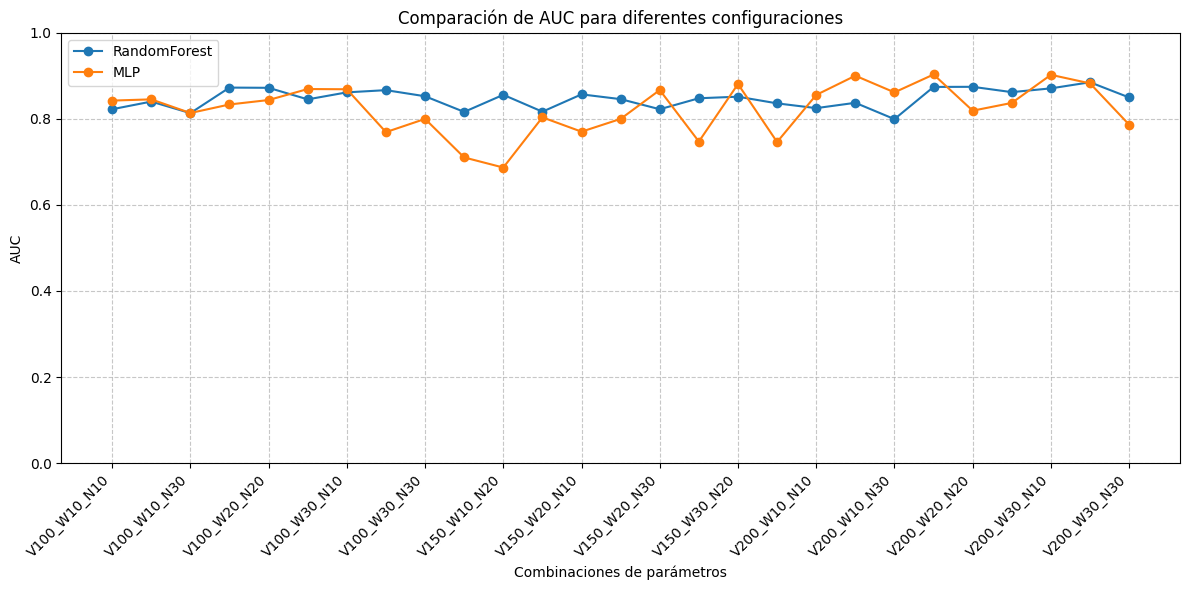


Creando visualización en heatmap para múltiples parámetros...


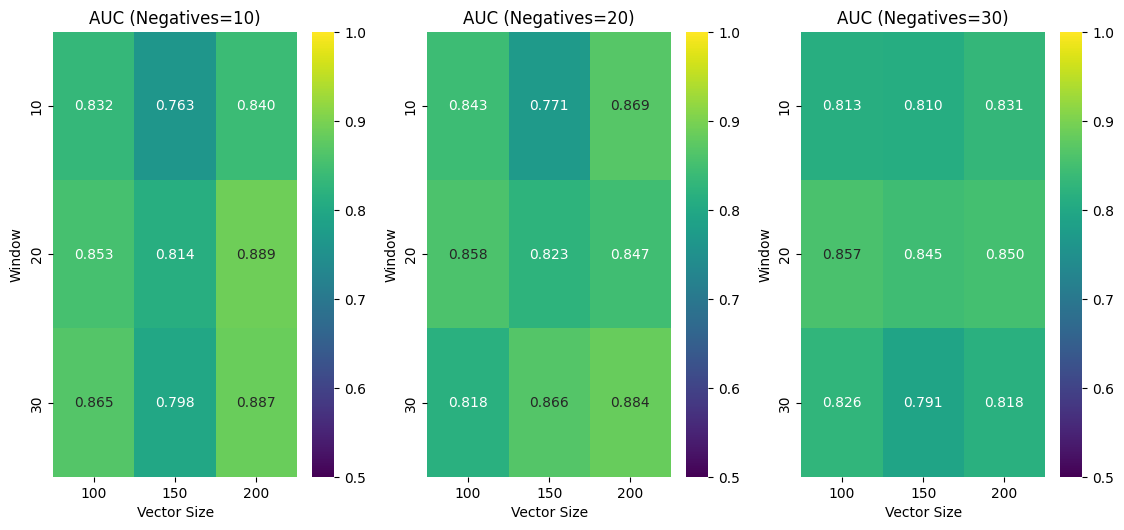

In [481]:
run_experiments(vector_sizes = [100, 150, 200],window_sizes=[10, 20, 30],negatives_sizes=[10, 20, 30])

A multilayer perceptron (MLP) was chosen due to its ability to learn complex and nonlinear patterns, which is useful in spam classification, as it can capture abstract relationships between words in a sentence. Although it is not ideal to use a complex model without first testing simpler ones, MLP was selected to evaluate its performance compared to a model like Random Forest, exploring whether the added complexity of the neural network improves spam prediction.